In [134]:
import pandas as pd # process and manipulate table data, implementing operations such as loading, aligning, merging, and transforming datasets efficiently
import numpy as np # numerical computing library for working with arrays and matrices, providing mathematical functions to operate on these data structures
import matplotlib.pyplot as plt # plotting library for creating static, animated, and interactive visualizations in Python
import matplotlib.dates as mdates
import os   # operating system interfaces for file and directory manipulation
import warnings # warning control to suppress or manage warning messages
import gsw  # Gibbs SeaWater (TEOS-10) oceanographic toolbox for seawater property calculations
print('gsw version:', gsw.__version__)

# Suppress pandas parsing warnings

gsw version: 3.6.21


# Load Data 

This code loads raw OWLR sensor data, cleans and filters rainfall-mode water level measurements, converts them to water surface elevation, and aggregates them into hourly averages for analysis within a defined time window.

In [135]:


# Paths & time window

data_dir  = "Data"
owlr_path = os.path.join(data_dir, "waterLevel_OWLR_VP_06152026.csv")
wse_CTD_path = os.path.join(data_dir, "wse_meterCTD_06162026.csv")
temp_davis_path = os.path.join(data_dir, "temp_Davis_06172026.csv")

start_time = pd.Timestamp("2026-05-04 12:00:00")
end_time   = pd.Timestamp("2026-06-14 23:00:00")
owlr_wse_offset_cm = 860.24


# Load OWLR (rainfall rows only)

cols = [
    "device_id", "timestamp", "unused_1", "data_type",
    "epoch", "OWLR_value_cm", "rain_mm_raw", "col7", "col8"
]

owlr_raw = pd.read_csv(owlr_path, header=None, names=cols)

owlr_raw["timestamp"] = pd.to_datetime(owlr_raw["timestamp"], errors="coerce")
owlr_raw = owlr_raw[owlr_raw["data_type"] == "rainfall"].copy()

# Parse OWLR_value_cm directly; if missing, fall back to payload value in epoch
owlr_raw["OWLR_value_cm"] = pd.to_numeric(owlr_raw["OWLR_value_cm"], errors="coerce")
epoch_value = pd.to_numeric(
    owlr_raw["epoch"].astype(str).str.split(",").str[1],
    errors="coerce"
 )
owlr_raw["OWLR_value_cm"] = owlr_raw["OWLR_value_cm"].fillna(epoch_value)

owlr_raw["WSE_OWLR_cm"] = owlr_wse_offset_cm - owlr_raw["OWLR_value_cm"]

owlr = owlr_raw[
    owlr_raw["timestamp"].notna()
    & (owlr_raw["timestamp"] >= start_time)
    & (owlr_raw["timestamp"] <= end_time)
] .copy()

owlr["timestamp_hour"] = owlr["timestamp"].dt.floor("h")
owlr = owlr.groupby("timestamp_hour", as_index=False)["WSE_OWLR_cm"].mean()

print(f"Window: {start_time} to {end_time}")
print(f"OWLR (rainfall) hourly points: {len(owlr)}")
print(owlr.tail())


Window: 2026-05-04 12:00:00 to 2026-06-14 23:00:00
OWLR (rainfall) hourly points: 979
         timestamp_hour  WSE_OWLR_cm
974 2026-06-14 19:00:00    716.20111
975 2026-06-14 20:00:00    714.98028
976 2026-06-14 21:00:00    714.82472
977 2026-06-14 22:00:00    714.38583
978 2026-06-14 23:00:00    714.23167


# Load CTD Data

This function loads CTD datad, cleans and converts timestamps and depth values, filters to a specified time window, and aggregates the data into hourly mean water surface elevation after applying a fixed offset conversion.

It returns a standardized hourly CTD dataset with water surface elevation in centimeters for downstream comparison with OWLR data.

In [136]:

def load_ctd(path):
    for enc in ["utf-8", "cp1252", "latin1"]:
        try:
            df = pd.read_csv(path, skiprows=5, encoding=enc)
            break
        except UnicodeDecodeError:
            continue

    df.columns = df.columns.str.strip()
    tcol, dcol = df.columns[:2]

    df[tcol] = pd.to_datetime(df[tcol], errors="coerce")
    df[dcol] = pd.to_numeric(df[dcol], errors="coerce")

    # Keep all valid timestamps (DO NOT filter minute/second)
    df = df[df[tcol].notna()]

    # time window filter
    df = df[(df[tcol] >= start_time) & (df[tcol] <= end_time)]

    # hourly binning (this is the correct step)
    df["timestamp_hour"] = df[tcol].dt.floor("h")

    df["WSE_CTD_cm"] = df[dcol] + 690.76

    # true hourly aggregation
    df = (
        df.groupby("timestamp_hour", as_index=False)["WSE_CTD_cm"]
        .mean()
    )

    return df


CTD_hourly = load_ctd(wse_CTD_path)

# Load OWLR

The OWLR dataset is loaded from a raw CSV file with manually assigned column names, and timestamp, distance, and rainfall values are converted to appropriate numeric formats. Only rows labeled as “rainfall” are retained, and water surface elevation is calculated using a fixed offset applied to the measured sensor distance.

The cleaned data are then filtered to the study period, aggregated to hourly resolution, and summarized as mean hourly water surface elevation for downstream analysis.

In [137]:
# -----------------------------
# Load OWLR (retain both raw and hourly data)
# -----------------------------
cols = [
    "device_id", "timestamp", "unused_1", "data_type",
    "epoch", "OWLR_value_cm", "rain_mm_raw", "col7", "col8"
]

owlr_raw = pd.read_csv(owlr_path, header=None, names=cols)

owlr_raw["timestamp"] = pd.to_datetime(owlr_raw["timestamp"], errors="coerce")
owlr_raw["OWLR_value_cm"] = pd.to_numeric(owlr_raw["OWLR_value_cm"], errors="coerce")
owlr_raw["rain_mm_raw"] = pd.to_numeric(owlr_raw["rain_mm_raw"], errors="coerce")

# Keep only rainfall rows; exclude variants like rainfall_0001
owlr_raw = owlr_raw[owlr_raw["data_type"].astype(str).str.strip().eq("rainfall")].copy()

owlr_raw["WSE_OWLR_cm"] = owlr_wse_offset_cm - owlr_raw["OWLR_value_cm"]

owlr = owlr_raw[
    owlr_raw["timestamp"].notna()
    & (owlr_raw["timestamp"] >= start_time)
    & (owlr_raw["timestamp"] <= end_time)
] .copy()

owlr["timestamp_hour"] = owlr["timestamp"].dt.floor("h")

owlr = (
    owlr.groupby("timestamp_hour", as_index=False)["WSE_OWLR_cm"]
    .mean()
)

In [138]:
# -----------------------------
# Merge
# -----------------------------
comparison = (
    pd.merge(CTD_hourly, owlr, on="timestamp_hour", how="inner")
    .sort_values("timestamp_hour")
    .reset_index(drop=True)
)

print(f"Window: {start_time} to {end_time}")
print(f"CTD points: {len(CTD_hourly)}")
print(f"OWLR points: {len(owlr)}")
print(f"Matched points: {len(comparison)}")

print(f"Window: {start_time} to {end_time}")
print(f"OWLR (rainfall) hourly points: {len(owlr)}")
print(owlr.tail())

Window: 2026-05-04 12:00:00 to 2026-06-14 23:00:00
CTD points: 996
OWLR points: 979
Matched points: 979
Window: 2026-05-04 12:00:00 to 2026-06-14 23:00:00
OWLR (rainfall) hourly points: 979
         timestamp_hour  WSE_OWLR_cm
974 2026-06-14 19:00:00    716.20111
975 2026-06-14 20:00:00    714.98028
976 2026-06-14 21:00:00    714.82472
977 2026-06-14 22:00:00    714.38583
978 2026-06-14 23:00:00    714.23167


# Use air temperature data from Davis

The Davis temperature data are loaded using a fallback encoding system to ensure compatibility across file formats. The dataset is then cleaned by stripping column names, converting timestamps and temperature values to appropriate data types, and filtering to retain only valid hourly observations within the study period.

The final output is a sorted, standardized hourly time series of air temperature (°C), which is used for matching with hydrologic sensor data in subsequent analyses.

In [139]:
# Load Davis temperature (robust encoding + hourly filtering)

davis_temp_raw = None
for enc in ["utf-8", "cp1252", "latin1"]:
    try:
        davis_temp_raw = pd.read_csv(temp_davis_path, skiprows=5, encoding=enc)
        break
    except UnicodeDecodeError:
        continue

if davis_temp_raw is None:
    raise ValueError("Could not decode Davis temperature file.")

# Clean columns + select first two
davis_temp_raw.columns = davis_temp_raw.columns.str.strip()
tcol, temp_col = davis_temp_raw.columns[:2]

# Parse + clean
davis_temp_raw[tcol] = pd.to_datetime(davis_temp_raw[tcol], errors="coerce")
davis_temp_raw[temp_col] = pd.to_numeric(davis_temp_raw[temp_col], errors="coerce")

# Filter + keep hourly only
davis_temp_hourly = (
    davis_temp_raw.loc[
        davis_temp_raw[tcol].between(start_time, end_time)
        & davis_temp_raw[tcol].dt.minute.eq(0),
        [tcol, temp_col]
    ]
    .dropna()
    .rename(columns={tcol: "timestamp", temp_col: "davis_temp_C"})
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print(f"Window: {start_time} to {end_time}")
print(f"Davis hourly points: {len(davis_temp_hourly)}")
print(davis_temp_hourly.tail())

C:\Users\ppita\AppData\Local\Temp\ipykernel_22384\2398858371.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  davis_temp_raw[tcol] = pd.to_datetime(davis_temp_raw[tcol], errors="coerce")


Window: 2026-05-04 12:00:00 to 2026-06-14 23:00:00
Davis hourly points: 996
              timestamp  davis_temp_C
991 2026-06-14 19:00:00          29.8
992 2026-06-14 20:00:00          28.1
993 2026-06-14 21:00:00          27.7
994 2026-06-14 22:00:00          27.4
995 2026-06-14 23:00:00          26.9


# Conversion for the varying speed of sound in air given varying temperature.

This code first ensures both OWLR and Davis hourly temperature datasets are available, then merges them on hourly timestamps to align water level and air temperature measurements. It reconstructs the original OWLR distance from water surface elevation and applies a temperature-based speed of sound correction to adjust the distance values.

Implement a conversion for the varying speed of sound in air given varying temperature.

Recommended steps (partial):


The distance sensor's datasheet says to assume distances use a speed of sound at 20 ºC. Knowing the speed of sound at 20 ºC and the measured distance, the amount of time for the pulse to travel from the sensor to the water then back to the sensor can be calculated (distance = rate x time). NB: the distance in this equation is actually 2x the distance reported by the sensor.

With the amount of time for a round-trip pulse now known, use a temperature-sensitive sound speed to recalculate distance (first the round-trip distance, then halving it to get actual distance from sensor to water).

Use a reliable nearby temperature record. The ILM station is the best for the wider region but other reliable sources exist including some of the CORMP time-series such as what you've already pulled as well as the colocated Davis station.

In [140]:
if "owlr" not in globals() or "davis_temp_hourly" not in globals():
    raise ValueError("Run the OWLR and Davis temperature loading cells first.")

# Match hourly OWLR water levels with hourly Davis air temperature
df = owlr.copy()
temp_hourly = davis_temp_hourly.rename(
    columns={"timestamp": "timestamp_hour", "davis_temp_C": "air_temp_C"}
).copy()

df = pd.merge(
    df,
    temp_hourly[["timestamp_hour", "air_temp_C"]],
    on="timestamp_hour",
    how="left",
)

# Reconstruct the one-way sensor distance from WSE before applying sound-speed correction
df["OWLR_value_cm"] = owlr_wse_offset_cm - df["WSE_OWLR_cm"]

reference_sound_speed_mps = 343.14
sound_speed_air_mps = 331.3 + 0.606 * df["air_temp_C"]
roundtrip_distance_cm = 2 * df["OWLR_value_cm"]

time_travel_s = roundtrip_distance_cm / reference_sound_speed_mps
owlr_corrected_cm_roundtrip = sound_speed_air_mps * time_travel_s
owlr_corrected_cm = owlr_corrected_cm_roundtrip / 2

# Preserve the existing variable name used by later cells
OWLR_corrected_cm = owlr_corrected_cm

In [141]:
comparison_head = df[["timestamp_hour", "OWLR_value_cm", "air_temp_C"]].copy()
comparison_head["OWLR_corrected_cm"] = OWLR_corrected_cm

print("Raw vs corrected OWLR values (head):")
print(comparison_head.head())

Raw vs corrected OWLR values (head):
       timestamp_hour  OWLR_value_cm  air_temp_C  OWLR_corrected_cm
0 2026-05-04 12:00:00      51.718058        20.9          51.842462
1 2026-05-04 13:00:00     123.827770        22.3         124.431789
2 2026-05-04 14:00:00     123.220830        22.1         123.778365
3 2026-05-04 15:00:00     122.988890        22.3         123.588817
4 2026-05-04 16:00:00     122.727780        22.4         123.348107


In [142]:
if "df" not in globals() or "OWLR_corrected_cm" not in globals():
    raise ValueError("Run the OWLR correction cell first.")

OWLR_wse_corrected = df[["timestamp_hour"]].copy()
OWLR_wse_corrected["OWLR_wse_corrected"] = owlr_wse_offset_cm - OWLR_corrected_cm

print(OWLR_wse_corrected.head(50))

        timestamp_hour  OWLR_wse_corrected
0  2026-05-04 12:00:00          808.397538
1  2026-05-04 13:00:00          735.808211
2  2026-05-04 14:00:00          736.461635
3  2026-05-04 15:00:00          736.651183
4  2026-05-04 16:00:00          736.891893
5  2026-05-04 17:00:00          737.169025
6  2026-05-04 18:00:00          737.362914
7  2026-05-04 19:00:00          736.563281
8  2026-05-04 20:00:00          734.946317
9  2026-05-04 21:00:00          735.017268
10 2026-05-04 22:00:00          734.680610
11 2026-05-04 23:00:00          734.185299
12 2026-05-05 00:00:00          734.118840
13 2026-05-05 01:00:00          734.411845
14 2026-05-05 02:00:00          734.091513
15 2026-05-05 03:00:00          734.112997
16 2026-05-05 04:00:00          734.409718
17 2026-05-05 05:00:00          734.426141
18 2026-05-05 06:00:00          734.547071
19 2026-05-05 07:00:00          734.368850
20 2026-05-05 08:00:00          735.789071
21 2026-05-05 09:00:00          735.066653
22 2026-05-

# Plot of OWLR (before correction) and Hydros 21 over time

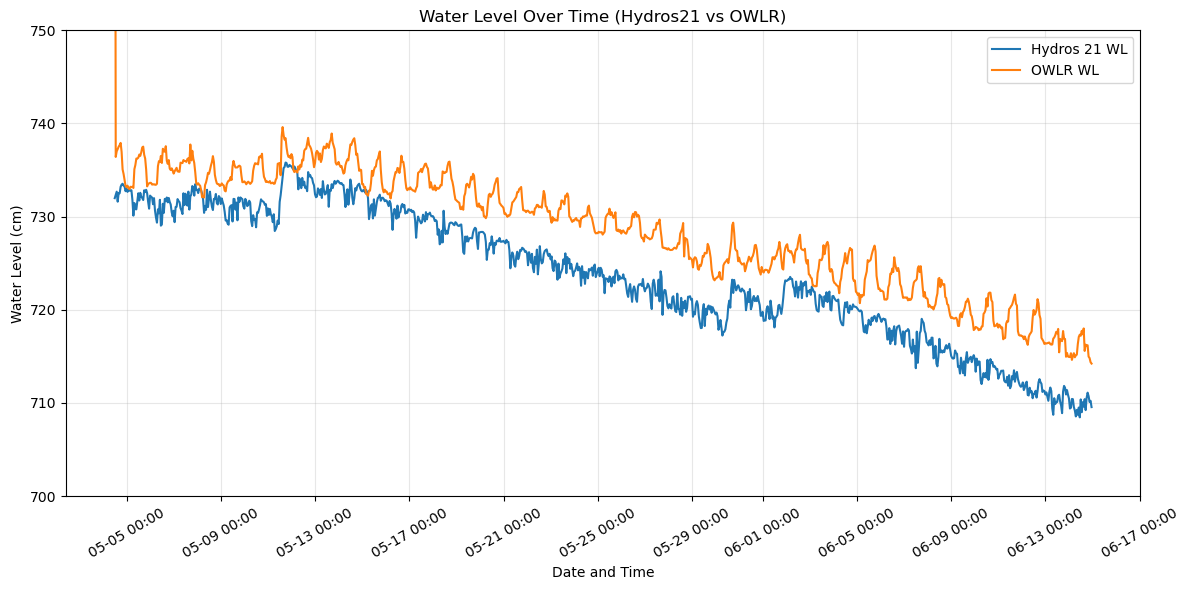

Hydros 21 points shown: 996
OWLR points shown: 979
Overlapping timestamps: 979


In [143]:

if 'CTD_hourly' not in globals() or 'owlr' not in globals():
    raise ValueError('Run the data-loading cell first.')

import matplotlib.dates as mdates

ctd_plot = CTD_hourly.sort_values('timestamp_hour').copy()
owlr_plot = owlr.sort_values('timestamp_hour').copy()

plt.figure(figsize=(12, 6))

plt.plot(
    ctd_plot['timestamp_hour'],
    ctd_plot['WSE_CTD_cm'],
    label='Hydros 21 WL'
 )

plt.plot(
    owlr_plot['timestamp_hour'],
    owlr_plot['WSE_OWLR_cm'],
    label='OWLR WL'
 )

plt.title('Water Level Over Time (Hydros21 vs OWLR)')
plt.xlabel('Date and Time')
plt.ylabel('Water Level (cm)')
plt.ylim(700, 750)

# Format x-axis ticks as mm-dd hh:mm
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=14))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=30)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

matched_only = pd.merge(
    ctd_plot[['timestamp_hour']],
    owlr_plot[['timestamp_hour']],
    on='timestamp_hour',
    how='inner'
 )

print(f'Hydros 21 points shown: {len(ctd_plot)}')
print(f'OWLR points shown: {len(owlr_plot)}')
print(f'Overlapping timestamps: {len(matched_only)}')

# Plot of OWLR (after correction) and Hydros 21 over time

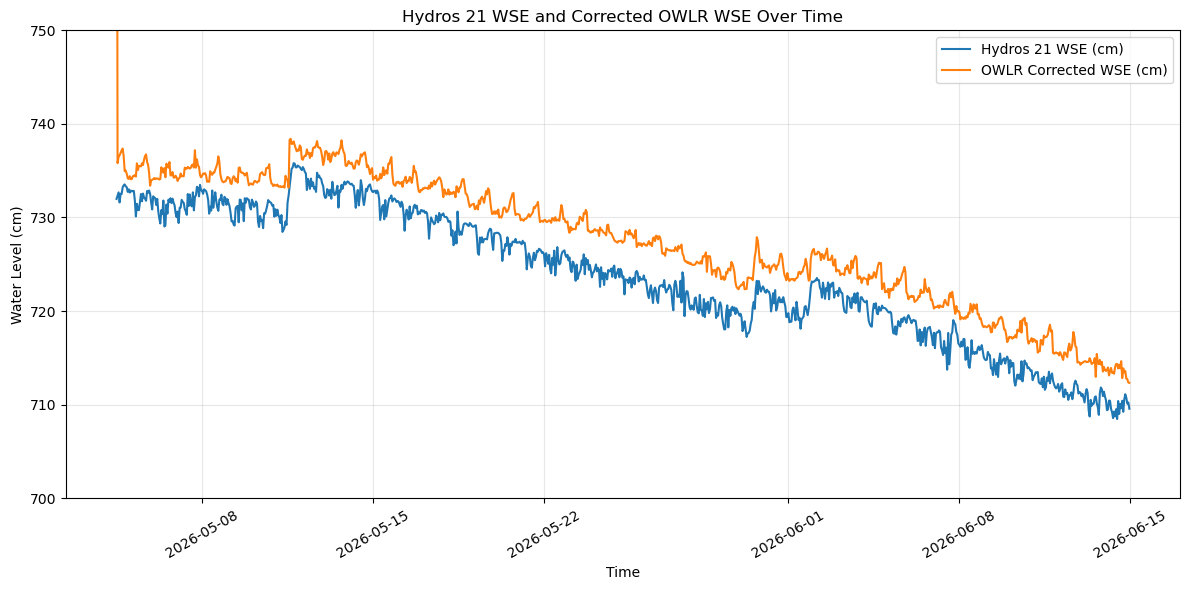

In [144]:
# Hydros 21 WSE and corrected OWLR WSE vs time
if "CTD_hourly" not in globals() or "OWLR_wse_corrected" not in globals():
    raise ValueError("Run the data-loading and OWLR WSE correction cells first.")

plot_df = OWLR_wse_corrected[["timestamp_hour", "OWLR_wse_corrected"]].copy()
plot_df = plot_df.dropna(subset=["timestamp_hour", "OWLR_wse_corrected"]).sort_values("timestamp_hour")

ctd_plot = CTD_hourly.dropna(subset=["timestamp_hour", "WSE_CTD_cm"]).sort_values("timestamp_hour")

plt.figure(figsize=(12, 6))
plt.plot(ctd_plot["timestamp_hour"], ctd_plot["WSE_CTD_cm"], label="Hydros 21 WSE (cm)")
plt.plot(plot_df["timestamp_hour"], plot_df["OWLR_wse_corrected"], label="OWLR Corrected WSE (cm)")

plt.title("Hydros 21 WSE and Corrected OWLR WSE Over Time")
plt.xlabel("Time")
plt.ylabel("Water Level (cm)")
plt.ylim(700, 750)
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Average difference between corrected and uncorrected OWLR WSE

In [145]:
if "owlr" not in globals() or "OWLR_wse_corrected" not in globals():
    raise ValueError("Run the OWLR WSE correction cells first.")

owrl_compare = pd.merge(
    owlr[["timestamp_hour", "WSE_OWLR_cm"]],
    OWLR_wse_corrected[["timestamp_hour", "OWLR_wse_corrected"]],
    on="timestamp_hour",
    how="inner",
)

owrl_compare["difference_cm"] = (
    owrl_compare["OWLR_wse_corrected"] - owrl_compare["WSE_OWLR_cm"]
)

mean_difference_cm = owrl_compare["difference_cm"].mean()
mean_absolute_difference_cm = owrl_compare["difference_cm"].abs().mean()

print(f"Average corrected minus uncorrected OWLR WSE: {mean_difference_cm:.3f} cm")
print(f"Average absolute difference: {mean_absolute_difference_cm:.3f} cm")

Average corrected minus uncorrected OWLR WSE: -0.903 cm
Average absolute difference: 1.152 cm
